# Pest Forecasting - Ontario Disease Risk

---

## Project context

This notebook is the reporting layer of the disease risk pipeline. It loads the processed daily risk table produced in Notebook 02 and generates two outputs: an interactive map showing station-level disease risk and spray status across Ontario for any selected date, and a static snapshot figure suitable for reports or automated alerts.

In production, this notebook runs on a daily schedule after Notebook 01 and 02 have completed. The map date is set to today automatically, requiring no manual input between runs.

## Inputs

| File | Description |
|---|---|
| `data/processed/daily_disease_risk.csv` | Daily DSV, risk category, cumulative score, and spray flags per station (from Notebook 02) |

## Outputs

| File | Description |
|---|---|
| `outputs/ontario_risk_map_{MAP_DATE}.html` | Interactive map - station markers colored by daily risk level, hover detail on click |
| `outputs/figures/03_risk_snapshot_{MAP_DATE}.png` | Static snapshot of station risk distribution for the selected date |

## 1. Environment setup

All imports, path constants, and color palettes are defined here. `MAP_DATE` is the single parameter that controls which day is visualised. In scheduled runs this is set to today automatically; it can be overridden to any date in the processed dataset for retrospective review.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import plotly.express as px
import warnings
from datetime import date
from pathlib import Path

warnings.filterwarnings('ignore', category=FutureWarning)

# -- Paths -------------------------------------------------------------------
PROC_PATH = Path('../data/processed/daily_disease_risk.csv')
OUTF      = Path('../outputs/figures/')
OUTM      = Path('../outputs/')

OUTF.mkdir(parents=True, exist_ok=True)
OUTM.mkdir(parents=True, exist_ok=True)

# -- Map date: set to today, or override to any date in the dataset ----------
MAP_DATE = str(date.today())   # e.g. '2025-09-24' to view a past date
MAP_DATE = "2025-09-24"   # for demonstration purposes, set to a specific date in the dataset

# -- Color palettes ----------------------------------------------------------
RISK_COLORS = {
    'LOW':       '#2ca25f',
    'MODERATE':  '#fdae61',
    'HIGH':      '#f46d43',
    'VERY HIGH': '#d7191c',
}

RISK_ORDER = ['LOW', 'MODERATE', 'HIGH', 'VERY HIGH']

print(f'Map date: {MAP_DATE}')

Map date: 2025-09-24


## 2. Load processed risk data and filter to map date

The full processed dataset is loaded and filtered to the selected date. A validation step confirms the date exists in the dataset and reports the risk distribution before rendering the map.

In [23]:
df = pd.read_csv(PROC_PATH, low_memory=False)
df['date'] = pd.to_datetime(df['date'])

map_date = pd.to_datetime(MAP_DATE)

assert map_date in df['date'].values, (
    f'MAP_DATE {MAP_DATE} not found in dataset. '
    f'Available range: {df["date"].min().date()} to {df["date"].max().date()}'
)

map_df = (
    df[df['date'] == map_date]
    .sort_values('date')
    .groupby('Station Name', as_index=False)
    .tail(1)
)

print(f'Stations on {MAP_DATE}: {len(map_df)}')
print()
print('Risk distribution:')
print(map_df['disease_risk'].value_counts().reindex(RISK_ORDER, fill_value=0).to_string())
print()
print('Spray recommendations:')
print(map_df['spray_recommendation'].value_counts().to_string())

Stations on 2025-09-24: 98

Risk distribution:
disease_risk
LOW          47
MODERATE     17
HIGH         13
VERY HIGH    21

Spray recommendations:
spray_recommendation
SPRAY 1     33
NO SPRAY    28
SPRAY 3     21
SPRAY 2     16


## 3. Interactive risk map

Each station is plotted at its geographic coordinates with marker color indicating the daily risk level. Hovering over a marker reveals the station name, daily DSV score, cumulative DSV, and spray recommendation. The map uses OpenStreetMap tiles and is fully zoomable.

The interactive version is saved as an HTML file that can be shared directly or embedded in a web dashboard. Stations with active spray recommendations are labeled directly on the map.

In [24]:
fig_map = px.scatter_map(
    map_df,
    lat='Latitude (y)',
    lon='Longitude (x)',
    hover_name='Station Name',
    hover_data={
        'date':                True,
        'dsv':                 True,
        'dsv_total':           True,
        'spray_recommendation': True,
        'Latitude (y)':        False,
        'Longitude (x)':       False,
    },
    color='disease_risk',
    color_discrete_map=RISK_COLORS,
    category_orders={'disease_risk': RISK_ORDER},
    zoom=5,
    height=650,
)

fig_map.update_layout(
    map_style='carto-positron',   # free, no API key, no referer required
    margin={'r': 0, 't': 30, 'l': 0, 'b': 0},
    title=f'Ontario Disease Risk - {MAP_DATE}',
    legend_title_text='Risk level',
)

fig_map.update_traces(
    marker=dict(size=14, opacity=0.7)
)

fig_map.show()

In [25]:
html_path = OUTM / f'ontario_risk_map_{MAP_DATE}.html'
fig_map.write_html(str(html_path))
print(f'Saved -> {html_path}')

Saved -> ..\outputs\ontario_risk_map_2025-09-24.html


## 4. Static risk snapshot figure

The interactive map cannot be embedded in email reports or PDF summaries. This static figure shows the same information as a scatter plot on a schematic Ontario coordinate space, using the same color encoding. Stations with active spray recommendations are annotated directly.

This figure is the format used in the automated daily alert email.

Saved -> ..\outputs\figures\03_risk_snapshot_2025-09-24.png


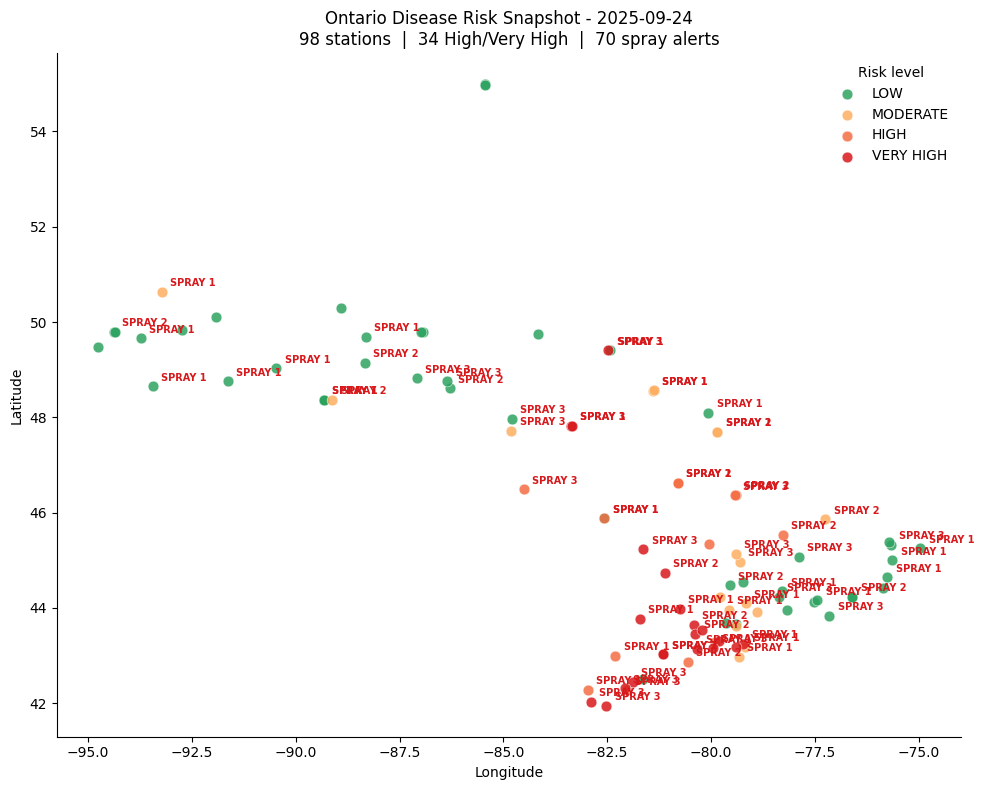

In [26]:
fig, ax = plt.subplots(figsize=(10, 8))

for risk in RISK_ORDER:
    subset = map_df[map_df['disease_risk'] == risk]
    ax.scatter(
        subset['Longitude (x)'],
        subset['Latitude (y)'],
        color=RISK_COLORS[risk],
        s=60, alpha=0.85, label=risk, zorder=3,
        edgecolors='white', linewidths=0.4,
    )

# Annotate stations with active spray recommendations
spray_stations = map_df[map_df['spray_recommendation'] != 'NO SPRAY']
for _, row in spray_stations.iterrows():
    ax.annotate(
        row['spray_recommendation'],
        xy=(row['Longitude (x)'], row['Latitude (y)']),
        xytext=(6, 4), textcoords='offset points',
        fontsize=7, color='#d7191c', fontweight='bold',
    )

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'Ontario Disease Risk Snapshot - {MAP_DATE}\n'
             f'{len(map_df)} stations  |  '
             f"{(map_df['disease_risk'].isin(['HIGH','VERY HIGH'])).sum()} High/Very High  |  "
             f"{(map_df['spray_recommendation'] != 'NO SPRAY').sum()} spray alerts")
ax.legend(title='Risk level', frameon=False)
ax.spines[['top', 'right']].set_visible(False)

fig.tight_layout()
snap_path = OUTF / f'03_risk_snapshot_{MAP_DATE}.png'
fig.savefig(snap_path, dpi=150, bbox_inches='tight')
print(f'Saved -> {snap_path}')

## 5. Network summary for selected date

A tabular summary of the highest-risk stations on the selected date, sorted by cumulative DSV. This table is the text component of the daily alert - it tells a recipient which specific locations need attention and how urgently.

In [27]:
summary = (
    map_df[['Station Name', 'disease_risk', 'dsv', 'dsv_total', 'spray_recommendation']]
    .sort_values('dsv_total', ascending=False)
    .reset_index(drop=True)
)

print(f'Network summary for {MAP_DATE}')
print(f'Total stations: {len(summary)}')
print()
print('Stations requiring attention (HIGH or VERY HIGH, or active spray flag):')
alert_stations = summary[
    summary['disease_risk'].isin(['HIGH', 'VERY HIGH']) |
    (summary['spray_recommendation'] != 'NO SPRAY')
]
print(alert_stations.to_string(index=False))

Network summary for 2025-09-24
Total stations: 98

Stations requiring attention (HIGH or VERY HIGH, or active spray flag):
                 Station Name disease_risk  dsv  dsv_total spray_recommendation
                KAPUSKASING A    VERY HIGH    4        528              SPRAY 3
                RIDGETOWN RCS    VERY HIGH    4        334              SPRAY 3
            SAULT STE MARIE A         HIGH    3        331              SPRAY 3
                   HAMILTON A    VERY HIGH    4        330              SPRAY 3
                   MARATHON A          LOW    0        286              SPRAY 3
            POINT PETRE (AUT)          LOW    1        272              SPRAY 3
                TOBERMORY RCS    VERY HIGH    4        271              SPRAY 3
                       WAWA A          LOW    1        269              SPRAY 3
          TERRACE BAY AIRPORT          LOW    1        260              SPRAY 3
               POINT PELEE CS    VERY HIGH    4        259              SPRAY

In [30]:
print(df['date'].min(), '-', df['date'].max())
print(df['date'].nunique(), 'unique dates')
print(df['station_id'].nunique(), 'stations')

2023-01-01 - 2025-12-31
1096 unique dates
98 stations


## Summary

| Item | Detail |
|---|---|
| Map date | Set by `MAP_DATE` constant in Section 1 - defaults to today |
| Interactive output | HTML file with hover detail per station |
| Static output | PNG snapshot with spray alert annotations |
| Alert table | Stations with HIGH or VERY HIGH risk, or active spray recommendation |
| Scheduling | Runs after Notebook 01 and 02 in daily pipeline; no manual input required |

This is the final notebook in the pipeline. The three notebooks together form a fully automated system: Notebook 01 keeps weather data current, Notebook 02 computes daily risk scores, and Notebook 03 produces the map and alert outputs for distribution.